## Forecasting example
In this example we will analyse a time series by estimating its components: trend, and offset. The observation equation for this time series follows the mathematical respresentation:

$$
Y(t) = y_0 + r t + \epsilon(t)
$$

We will follow the

### Step 0: Load data and plot
In the following code we plot the time series. From the plot, we can clearly identify a linear trend.

In [43]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

y0 = 100 # intercept
r = 2 # slope

# Parameters for the AR(1) process
sigma = 11          # Standard deviation of the noise
n = 100            # Length of the time series

# Initialize the process
np.random.seed(42)  # For reproducibility
noise_AR = np.zeros(n)
noise_AR[0] = np.random.normal(0, sigma)  # Initial value
t = np.arange(1900, 2000, 1)

print(len(t))

# Generate the AR(1) process and noise series
noise = np.random.normal(0, sigma, n)  # Pre-generate noise for the second plot
phi = 0.8
for lag in range(1, n):
        noise_AR[lag] = phi * noise_AR[lag-1] + noise[lag]  # Use pre-generated noise

# Add intercept and linear trend
data = y0 + r*t + noise_AR


100


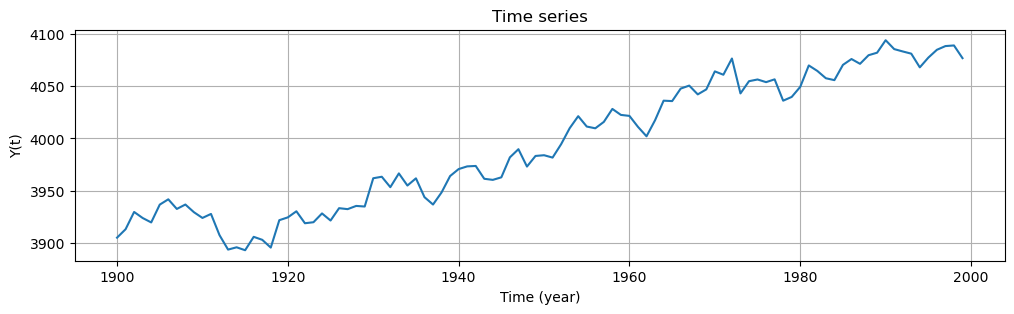

In [38]:
# Plot the time series
plt.figure(figsize=(12, 3))
plt.plot(t, data)
plt.title("Time series")
plt.xlabel("Time (year)")
plt.ylabel("Y(t)")
plt.grid(True)


### Step 1: Estimate the signal of interest

To estimate the linear trend and offset we can use the Least Squares estimator since we don't know the covariance matrix of the data. This is equivalent to fitting a linear model to the time series.

The observation equation is written as:

$$
Y(t) = y_0 + r t + o {u_k(t)} + \epsilon(t).
$$

Therefore, the linear functional model for the $500$ observables is expressed as:

$$
\mathbb{E}(\underset{\mathrm{Y}}{\underbrace{\begin{bmatrix} Y_1 \\ \vdots \\ Y_{500} \end{bmatrix}}} )= \underset{\mathrm{A}}{\underbrace{\begin{bmatrix} 1 & t_1 \\ \vdots & \vdots  \\  1 & t_{500} \end{bmatrix}}}\underset{\mathrm{x}}{\underbrace{\begin{bmatrix} y_0 \\ r  \end{bmatrix}}},
$$

and the least-squares solution of the unknown parameter vector $\mathrm{x}$ is obtained as:

$$
\mathrm{\hat{X}= (A^T A)^{-1} A^T \mathrm{Y}}.
$$

The time series without the linear trend and offset is simply the residuals:

$$
\mathrm{\hat{e}}= \mathrm{Y} - A\mathrm{\hat{Y}}.
$$

In the following code we estimate the linear trend and offset and remove them from the time series.

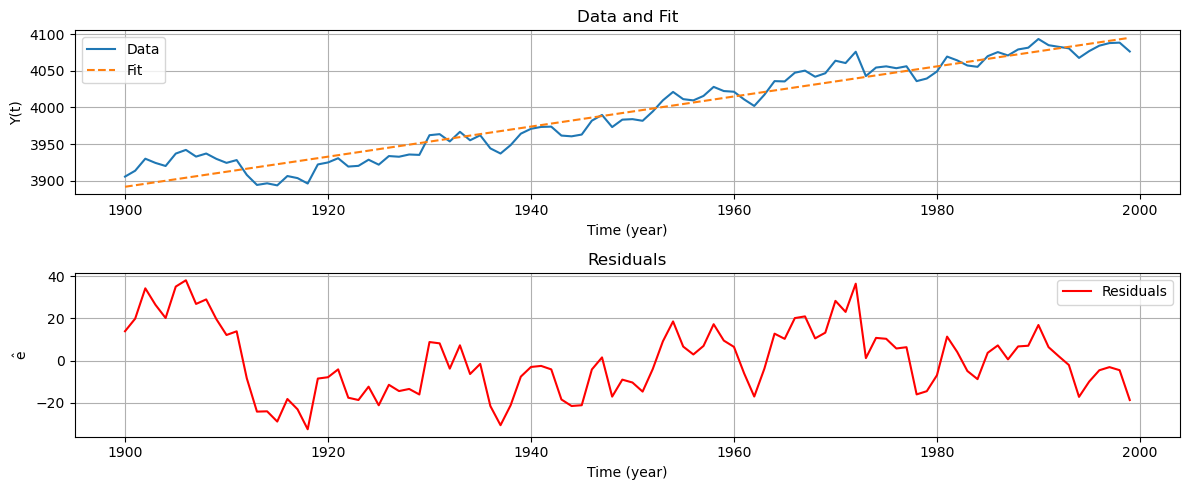

In [ ]:

A = np.column_stack((np.ones_like(t), t))
xhat = np.linalg.solve(A.T @ A, A.T @ data)
yhat = A @ xhat
ehat = data - yhat

fig, axs = plt.subplots(2, 1, figsize=(12, 5))

# Plot data and fit
axs[0].plot(t, data, label='Data')
axs[0].plot(t, yhat, label='Fit', linestyle='--')
axs[0].set_xlabel('Time (year)')
axs[0].set_ylabel('Y(t)')
axs[0].set_title('Data and Fit')
axs[0].legend()
axs[0].grid()

# Plot residuals
axs[1].plot(t, ehat, label='Residuals', color='red')
axs[1].set_xlabel('Time (year)')
axs[1].set_ylabel('$\mathrm{\hat{e}}$')
axs[1].set_title('Residuals')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


In the above plots the blue line represents the time series $\mathrm{Y}$, the dashed orange line is the fitted line using the previously defined functional model $\hat{\mathrm{Y}} = \mathrm{A}\hat{\mathrm{x}}$, and the red line represents the residuals $\mathrm{\hat{e}}$. We can identify a seasonal component in the residuals, meaning that they are not completely stationary. In the next step we will estimate this seasonal component.  

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


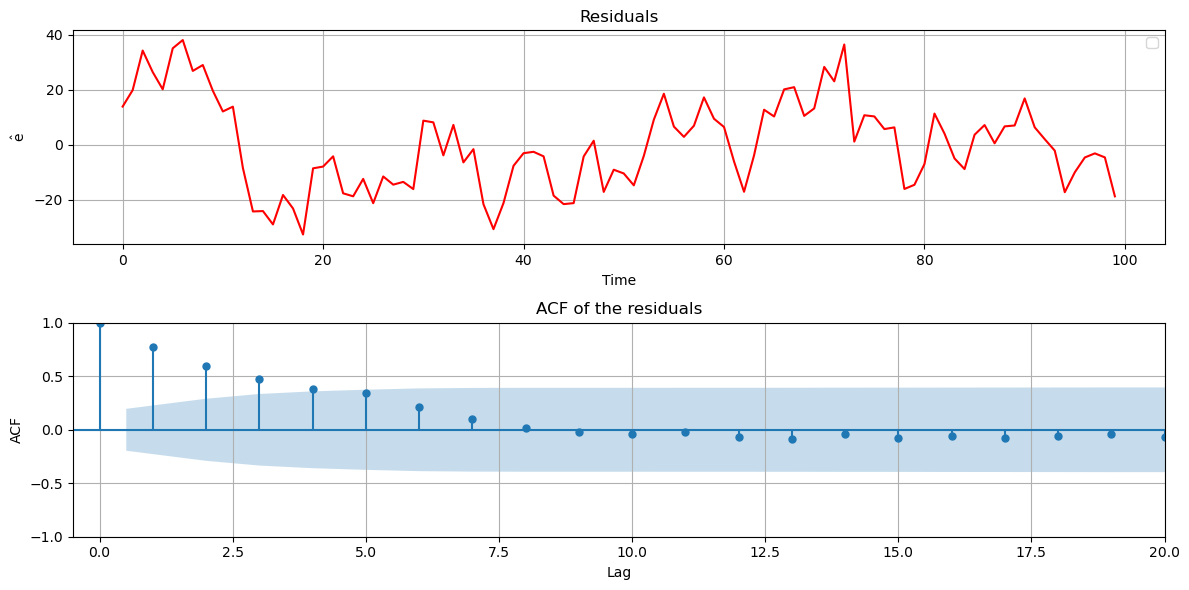

In [58]:
# Create the 2x1 subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# Plot the AR(1) process in the first subplot
ax1.plot(ehat,color='red')
ax1.set_ylabel('$\mathrm{\hat{e}}$')
ax1.set_title("Residuals")
ax1.set_xlabel("Time")
ax1.legend()
ax1.grid(True)

# Plot the white noise in the second subplot
lags = 20
plot_acf(ehat, ax=ax2, lags=lags, title="ACF of White Noise")
ax2.set_xlabel("Lag")
ax2.set_ylabel("ACF Value")
ax2.set_title("ACF of the residuals")
ax2.set_xlim(-0.5, lags)
ax2.set_xlabel("Lag")
ax2.set_ylabel("ACF")
ax2.grid(True)


# Display the plot
plt.tight_layout()
plt.show()

### Step 2: Model the noise using the AR(1) model
a

AR(1) Coefficient:
Phi_1 =  0.7642


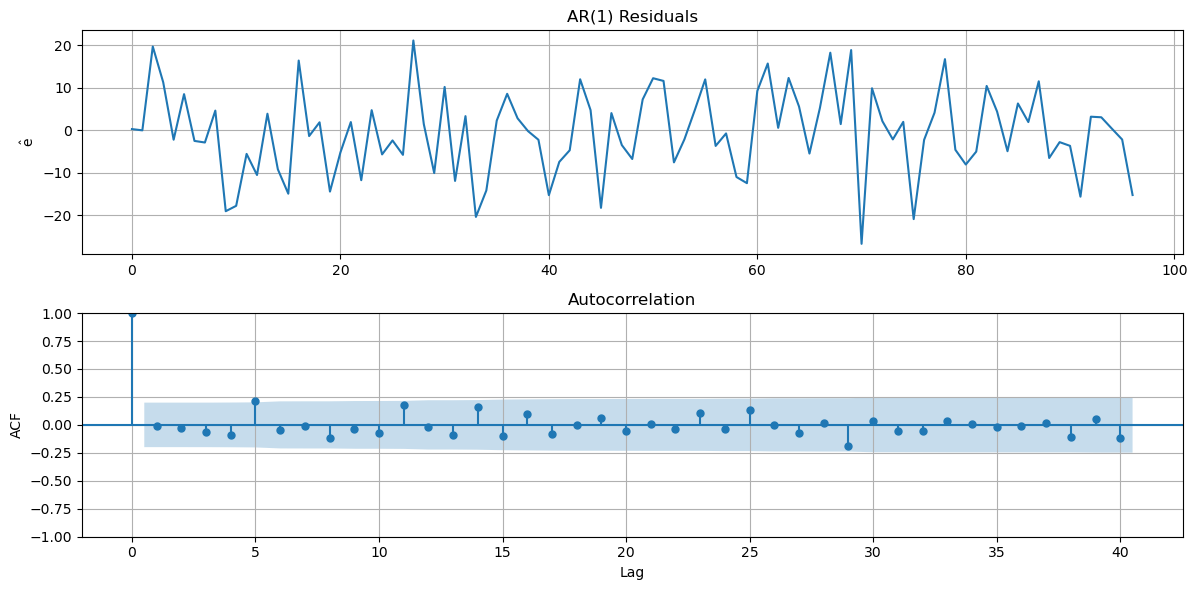

In [59]:
y = ehat[3:]
s1 = ehat[2:-1]

# AR(1) model
X1 = np.column_stack((s1)).T
phi_ar1 = np.linalg.inv(X1.T @ X1) @ (X1.T @ y)
e1 = y - X1 @ phi_ar1


fig, ax = plt.subplots(2,1,figsize=(12, 6))
ax[0].plot(e1)
ax[0].set_title('AR(1) Residuals')
ax[0].set_ylabel('$\mathrm{\hat{e}}$')
ax[0].grid(True)

plot_acf(e1, lags=40, ax=ax[1])
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("ACF")
ax[1].grid(True)

fig.tight_layout()

# print the AR(2) coefficients with confidence intervals
print('AR(1) Coefficient:')
print('Phi_1 = ', round(phi_ar1[0], 4))

### Step 3: Predict the signal-of-interest for year 2000




$$
\mathrm{\hat{Y}_{2000}}=  \underset{A_p}{\underbrace{\begin{bmatrix} 1 & 2000 \end{bmatrix}}} \underset{\hat{\mathrm{X}}}{\underbrace{\begin{bmatrix} \hat{y}_0 \\ \hat{r}  \end{bmatrix}}}.
$$

### Step 4: Predict the noise for year 2000
a

### Step 5: Predict the time series for year 2000
a

$$
\mathrm{\hat{Y}_{2000}}=  \underset{A_p}{\underbrace{\begin{bmatrix} 1 & 2000 \end{bmatrix}}} \underset{\hat{\mathrm{X}}}{\underbrace{\begin{bmatrix} \hat{y}_0 \\ \hat{r}  \end{bmatrix}}} + \hat{\epsilon}_p.
$$